# 그래프와 시각화
정보 시각화(plot, 플롯)는 데이터 분석에서 중요한 작업\
시각화는 특이값을 찾거나, 데이터 변형이 필요한지 알아보거나, 모델에 대한 아이디어를 찾기 위한 과정의 일부

맷플롯립은 주로 2D 그래프를 위한 데스크톱 패키지로 그래프를 만들고, 모든 운영체제의 다양한 GUI 백엔드를 지원하며, PDF, SVG, JPG, PNG, BMP, GIF 등 일반적으로 널리 사용하는 벡터와 래스터 형식으로 그래프를 저장할 수 있음

## 1. 맷플롯립 API 간단하게 살펴보기
맷플롯립은 다음 컨벤션으로 import함 

In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

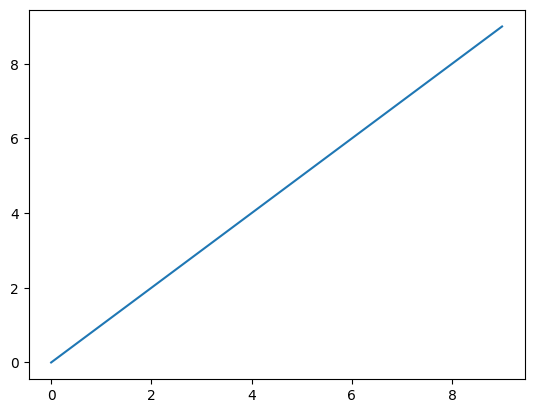

In [3]:
plt.plot(data)

### 1.1 figure, subplot
맷플롯립에서 그래프는 피겨(figure) 객체 내에 존재함\
새로운 피겨는 plt.figure 로 생성함

In [4]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

plt.figure에는 다양한 옵션이 있는데, figsize로 파일로 저장할 피겨의 크기와 비율을 지정할 수 있음\
빈 피겨 객체로는 그래프를 만들 수 없으며 add_subplot을 사용해 최소 하나 이상의 subplots를 생성해야 함

In [5]:
ax1 = fig.add_subplot(2,2,1)

위 코드는 fig 객체는 2x2 크기이고 네 개의 서브플롯 중에서 첫 번째를 선택하겠다는 의미(서브플롯은 1부터 숫자가 매겨짐)\
아래처럼 두 개의 서브플롯을 더 추가해보자

In [6]:
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)

주피터 노트북을 사용할 때는 실행되는 셀마다 그래프가 리셋되므로 단일 셀에 그래프를 그리는 코드를 전부 입력해야 함

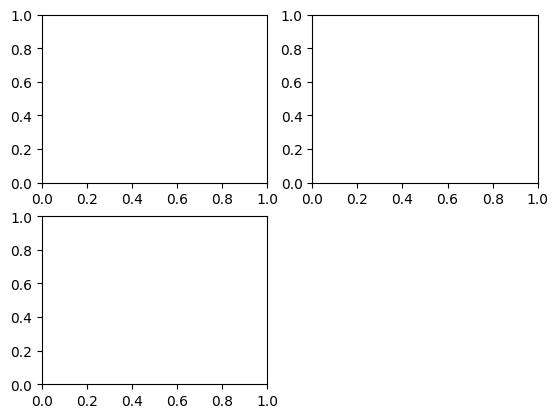

In [8]:
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)

ㅁx 객체는 다양한 종류의 그래프를 그리는 여러 메서드를 지원하는데 plt.plot 같은 최상위 함수를 사용하는 것보다 이 객체 메서드를 사용하는 것이 좋음\
예를 들어 plot 메서드로 다음과 같은 선 그래프를 그릴 수 있음

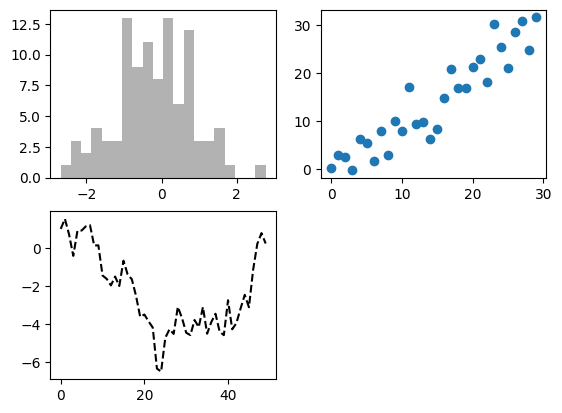

In [15]:
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax1.hist(np.random.standard_normal(100),bins=20, color='black', alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color='black',linestyle='dashed')

alpha = 0.3 스타일 옵션은 겹쳐서 그려진 그래프의 투명도를 설정함

맷플롯립은 특정한 배치에 맞춰 여러 개의 서브 플롯을 쉽게 만들 수 있도록 plt.subplots 메서드를 제공함\
이 메서드는 새로운 피겨 객체를 생성하고 생성된 서브플롯 객체를 담은 넘파이 배열을 반환함

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

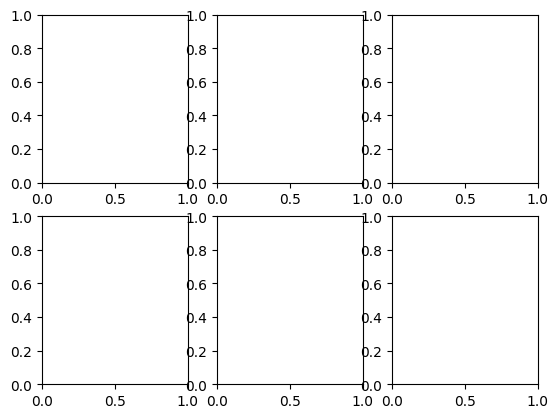

In [17]:
fig, axes = plt.subplots(2,3)
axes

axes 배열은 2차원 배열처럼 색인할 수 있는데, 예를 들어 axes[0, 1]은 1행 2열에 있는 서브플롯을 참조함\
서브플롯이 동일한 x축이나 y축을 가져야 한다면 각각 sharex와 sharey를 사용해서 지정함\
이는 동일한 범위 내에서 데이터를 비교해야 할 경우 특히 유용하며 그렇지 않으면 맷플롯립은 각 그래프의 범위를 독립적으로 조정함

__matplotlib.pyplot.subplots옵션__
|인수|설명|
|:--|:--|
|nrows|서브플롯의 행 수|
|ncols|서브플롯의 열 수|
|sharex|모든 서브플롯이 동일한 x축 눈금을 사용하도록 함(xlim 값을 조절하면 모든 서브플롯에 적용됨)|
|sharey|모든 서브플롯이 동일한 y축 눈금을 사용하도록 함(ylim 값을 조절하면 모든 서브플롯에 적용됨)|
|subplot_kw|add_subplot을 사용해서 각 서브플롯을 생성할 때 사용할 키워드를 담고 있는 딕셔너리|
|**fig_kw|피겨를 생성할 때 사용할 추가적인 키워드 인수 <br> 예를 들면 plt.subplots(2, 2, figsize=(8, 6))와 같음|

__서브플롯 간 간격 조절하기__\
맷플롯립은 서브플롯 간의 적당한 간격(spacing)과 여백(padding)을 기본적으로 추가함\
이 간격은 전체 그래프의 높이와 너비에 따라 상대적으로 결정되므로 프로그램을 이용하거나 GUI 윈도우 크기를 직접 조정하면 크기가 자동으로 조절됨\
서브플롯 간의 간격은 피겨 객체의 subplots_adjust 메서드로 쉽게 조정할 수 있음
```py
subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
```
wspace와 hspace는 서브플롯 간의 간격을 위해 각 피겨의 너비와 높이에 대한 비율을 조절함

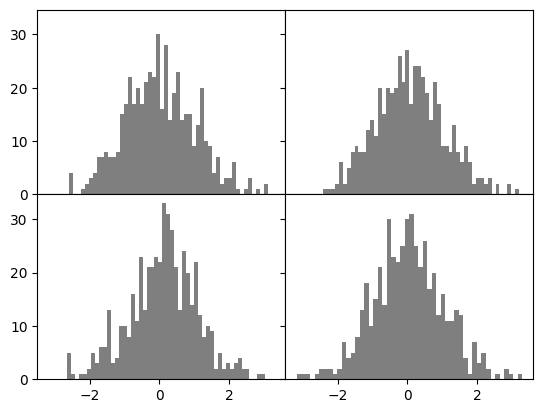

In [18]:
fig, axes= plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i,j].hist(np.random.standard_normal(500), bins=50, color='black', alpha=0.5)

fig.subplots_adjust(wspace=0, hspace=0)

### 1.2 색상, 마커, 선 스타일
맷플롯립의 plot 함수는 x와 y의 좌표값이 담긴 배열과 추가적으로 색상과 선 스타일 옵션을 인수로 받음\
예를 들어 녹색 점선으로 그려진 x 대 y 그래프의 코드는 다음과 같음

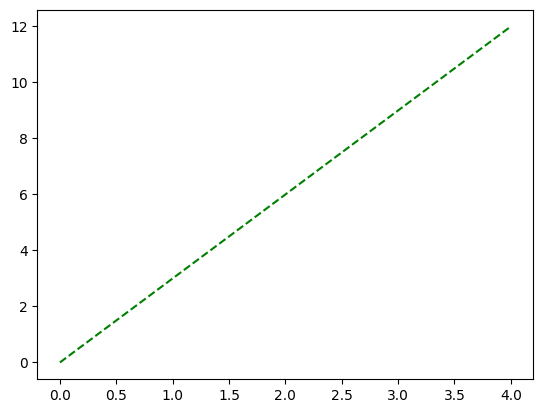

In [21]:
x = np.arange(5)
y = 3 * x
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(x,y, linestyle='--', color='green')

흔하게 사용하는 색상에는 색상 문자열(green)을 제공하지만 헥스 코드(hex code)를 직접 지정하면 색상표에 있는 모든 색상을 사용할 수 있음\
plt.plot 메서드 문서에서 지원하는 선 스타일 종류를 참고할 수 있음

선 그래프는 특정 지점의 실제 데이터를 강조하기 위해 마커(marker)를 추가하기도 함\
맷플롯립은 점들을 잇는 연속된 선 그래프를 생성하므로 어떤 지점에 마커를 설정해야 하는지 확실치 않은 경우가 종종 있음

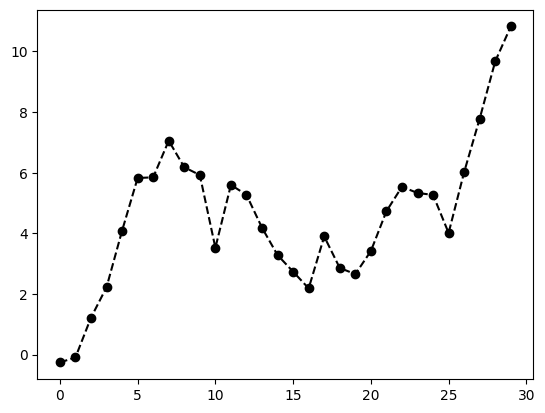

In [23]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color='k', linestyle='dashed', marker='o')

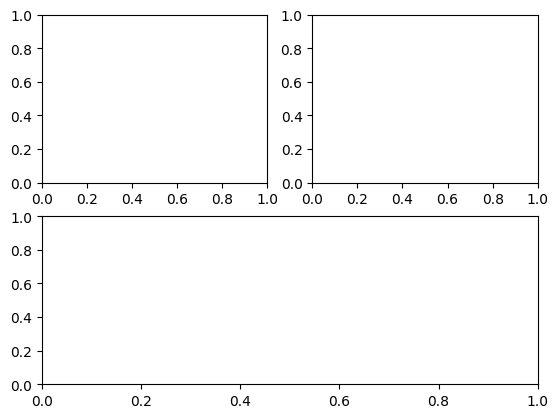

In [ ]:
# add_subplot을 이용할 때의 장점 - 불균등 그리드
fig = plt.figure()

ax1 = fig.add_subplot(2, 2, 1)   # 2×2 중 1번
ax2 = fig.add_subplot(2, 2, 2)   # 2×2 중 2번
ax3 = fig.add_subplot(2, 1, 2)   # 하단 전체 (2×1 기준 2번째)

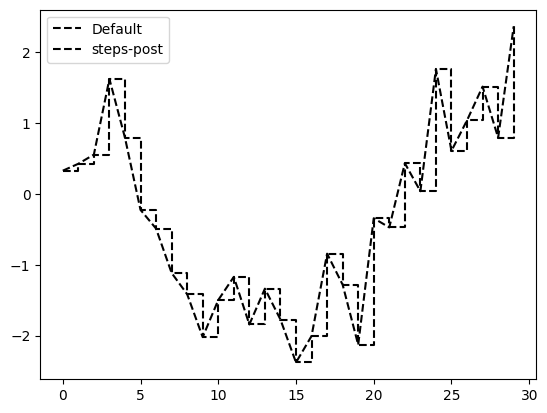

In [25]:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()

ax.plot(data, color = 'k', linestyle='dashed', label='Default')
ax.plot(data, color = 'k', linestyle='dashed', drawstyle='steps-post', label='steps-post')
ax.legend()

위에서는 label을 전달했기 때문에 ax.legend를 사용해 각 선을 구별하는 범례를 포함시켜 그래프를 생성하였음\
그래프를 그릴 때 범례를 생성하려면 label 옵션 지정 여부와는 상관없이 ax.legend를 호출해야 함

### 1.3 눈금, 레이블, 범례
그래프를 꾸미는 방법은 대부분 맷플롯립의 ax 객체 메서드로 접근할 수 있음\
xlim, xticks, xticklabels와 같은 메서드를 이용해 그래프의 범위를 지정하거나, 눈금 위치, 눈금 레이블을 설정할 수 있음
* 아무런 인수도 없이 호출하면 현재 설정된 매개변수값을 반환함 \
예를 들어 ax.xlim 메서드는 현재 x축의 범위를 반환함
* 매개변수를 전달하면 매개변수값을 설정함\
예를 들어 ax.xlim([0, 10])을 전달하면 x축의 범위가 0부터 10까지로 설정됨

모든 메서드는 현재 활성화되거나 가장 최근에 생성된 AxesSubplot 객체에 대해 작동함\
앞서 소개한 모든 메서드는 서브플롯 객체의 set/get 메서드로도 존재하며 xlim이라면 ax.get_xlim, ax.set_xlim 메서드가 존재함

__제목, 축 레이블, 눈금, 눈금 레이블 설정하기__\
축을 꾸미는 방법을 설명하기 위해 무작위로 간단한 그래프를 하나 생성

Text(0.5, 1.0, 'matplotlib plot')

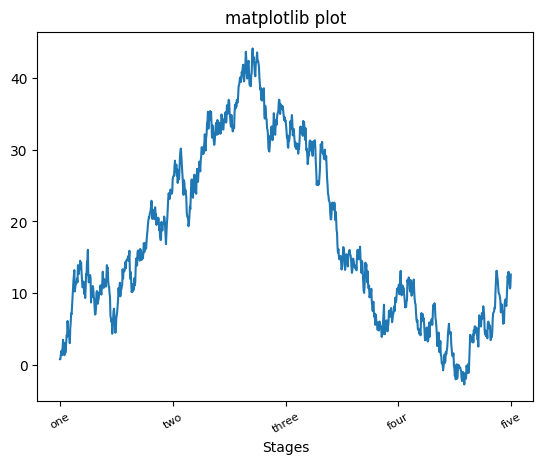

In [26]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize=8)
ax.set_xlabel('Stages')
ax.set_title('matplotlib plot')

x축의 눈금을 변경하는 가장 쉬운 방법은 set_xticks와 set_xticklabels 메서드를 사용하는 것\
set_xticks 메서드는 전체 데이터 범위에 따라 눈금을 어디에 배치할지 지정하며 기본적으로 이 위치에 눈금 레이블이 들어감\
하지만 다른 눈금 레이블을 지정하고 싶다면 set_xticklabels를 사용함\
rotation 옵션은 x축 눈금 레이블을 입력한 값만큼 회전시킴\
set_xlabel 메서드는 x축 이름을 지정하고 set_title 메서드는 서브플롯의 제목을 지정함\
x 대신에 y를 사용하면 y축도 꾸밀 수 있으며 ax 클래스는 그래프의 속성을 설정하는 set 메서드를 제공함

[Text(0.5, 1.0, 'matplotlib plot'), Text(0.5, 0, 'Stages')]

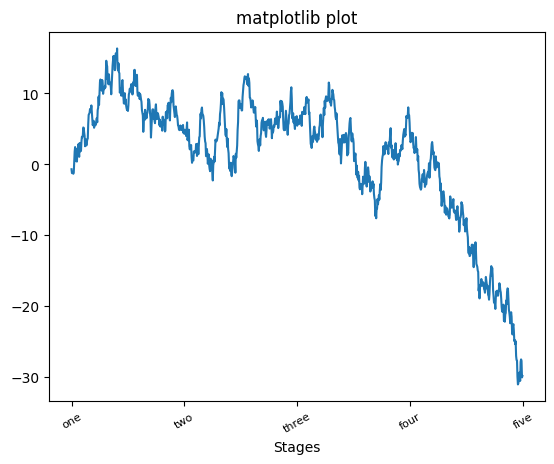

In [28]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize=8)
ax.set(title='matplotlib plot', xlabel='Stages')

__범례 추가하기__\
범례는 그래프의 요소를 확인하는 핵심 요소이며 범례를 추가하는 가장 쉬운 방법은 각 그래프에 label 인수를 넘기는 것임

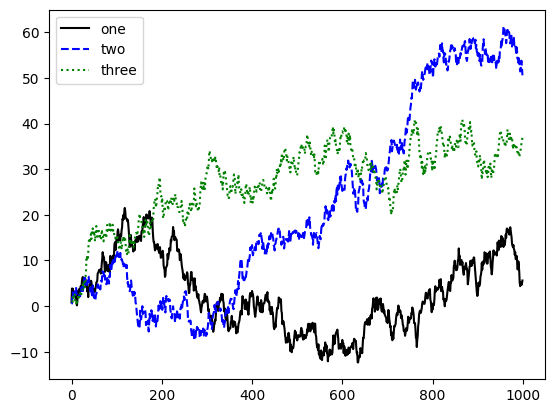

In [31]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color = 'k', label='one')
ax.plot(np.random.randn(1000).cumsum(), color = 'b', linestyle='dashed', label='two')
ax.plot(np.random.randn(1000).cumsum(), color = 'g', linestyle='dotted', label='three')
ax.legend()

### 1.4 주석과 그림 추가하기
기본 그래프에 글자나 화살표, 다른 도형으로 자신만의 주석을 추가하고 싶은 경우가 존재함\
주석과 글자는 text, arrow, annotate 함수를 이용해서 추가할 수 있음\
text 함수는 그래프 내의 주어진 좌표(x, y)에 부가적인 스타일로 글자를 그림

In [35]:
ax.text(x, y, "hello world!", family='monospace', fontsize=10)

Text([0 1 2 3 4], [ 0  3  6  9 12], 'hello world!')

주석에는 글자와 화살표를 함께 사용할 수 있음\
야후 파이낸스에서 얻은 2007년 이후의 S&P 500 지수 데이터로 그래프를 생성하고 2008-2009년 사이에 있었던 금융위기 중 중요한 날짜를 주석으로 추가해볼 것임

Text(0.5, 1.0, 'Important dates in the 2008–2009 financial crisis')

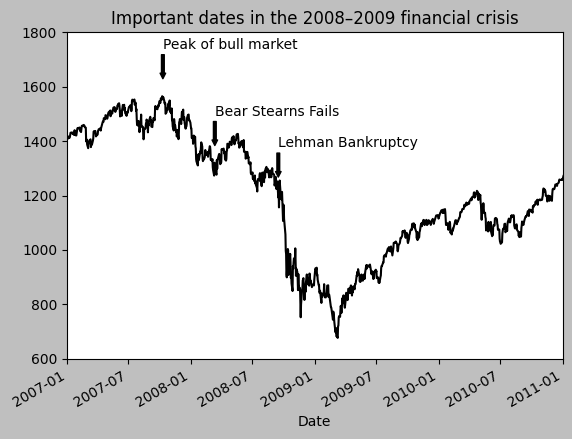

In [104]:
from datetime import datetime
import pandas as pd

fig, ax = plt.subplots()

data = pd.read_csv('https://github.com/wesm/pydata-book/blob/3rd-edition/examples/spx.csv?raw=True', index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                horizontalalignment="left", verticalalignment="top")

# Zoom in on 2007-2010
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008–2009 financial crisis")

### 1.5 그래프를 파일로 저장하기
활성화된 피겨는 savefig 메서드를 이용해 파일로 저장함

In [37]:
fig.savefig("figex.png", dpi=400)

## 2. seaborn으로 그래프 그리기
맷플롯립은 꽤 저수준의 라이브러리로 데이터를 어떻게 보여줄 것인지부터(선 그래프, 맏개그래프, 산포도, 등고선 등) 범례와 제목, 눈금 레이블, 주석 같은 기본 컴포넌트에서 그래프를 작성해야 함

판다스를 사용하다보면 행과 열 레이블을 가진 다양한 열 데이터를 다루게 됨\
판다스는 Series와 DataFrame 객체를 간단하게 시각화하는 내장 메서드를 제공함\
다른 라이브러리로는 맷플롯립 기반의 고차원 통계 그래픽 라이브러리인 시본(seaborn)이 있음

### 2.1 선 그래프
Series와 DataFrame은 plot 메서드로 다양한 형태의 그래프를 생성할 수 있음

<Axes: >

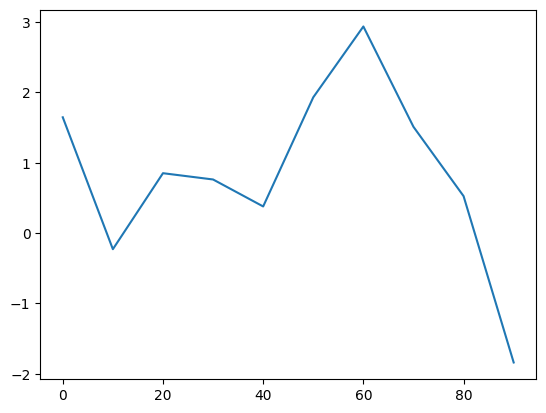

In [39]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

Series 객체의 색인은 맷플롯립에서 그래프를 생성할 때 x축으로 해석됨\
use_index=False 옵션을 넘기면 색인을 그래프의 축으로 사용하는 것을 막을 수 있음\
x축의 눈금과 한계는 xticks와 xlim 옵션으로 조절할 수 있으며 y축도 마찬가지임

대부분의 판다스 그래프 메서드는 부수적으로 ax 매개변수를 ㅏㅂㄷ는데, 이 매개변수는 맷플롯립의 서브플롯 객체가 될 수 있음\
이를 통해 그리드 배열상에서 서브플롯을 유연하게 배치할 수 있음

DataFrame의 plot 메서드는 하나의 서브플롯 안에 각 열별로 선 그래프를 그리고, 자동으로 범례를 생성함

<Axes: >

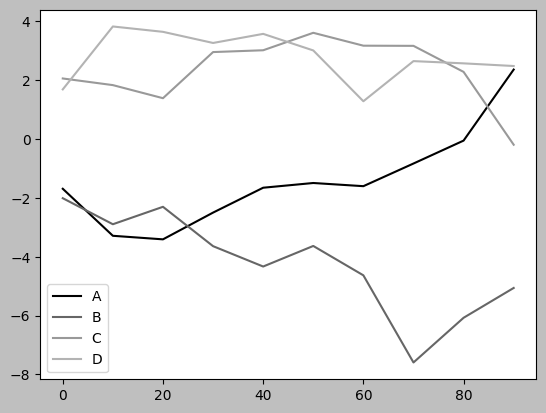

In [42]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot()

plot 속성에는 다양한 종류의 그래프 패밀리가 존재하는데, 예를 들어 df.plot()은 df.plot.line()과 동일함
(plot 메서드에 전달할 수 있는 부수적인 키워드 인수는 그대로 맷플롯립의 함수로 전달됨)

DataFrame에는 열을 쉽게 다루기 위한 몇 가지 옵션을 제공하는데, 예를 들어 모든 열을 동일한 서브플롯에 그릴 것인지 아니면 서브플롯을 각각 만들 것인지 지정할 수 있음

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

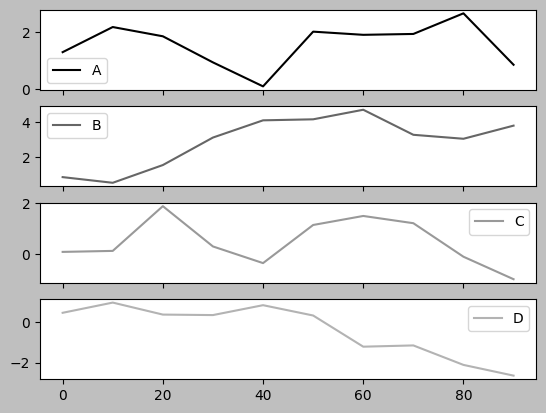

In [43]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot(subplots=True)

### 2.2 막대그래프
plot.bar()와 plot.barh()는 각각 수직 막대그래프, 수평 막대그래프를 그림\
Series 또는 DataFrame의 색인은 수직 막대그래프인 경우 x(bar) 눈금, 수평 막대 그래프의 경우 y(barh) 눈금으로 사용됨

<Axes: >

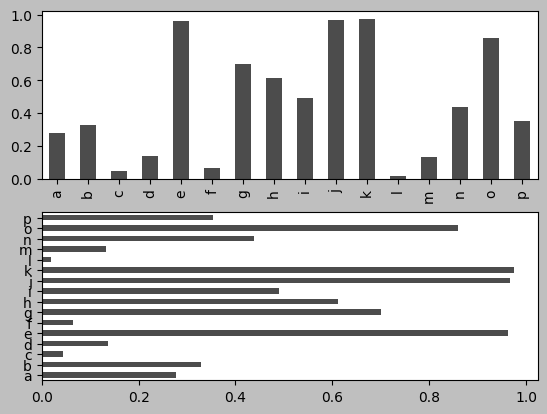

In [44]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

DataFrame에서 막대그래프는 각 행의 값을 함께 묶어서 하나의 그룹마다 각각의 막대를 보여줌

<Axes: >

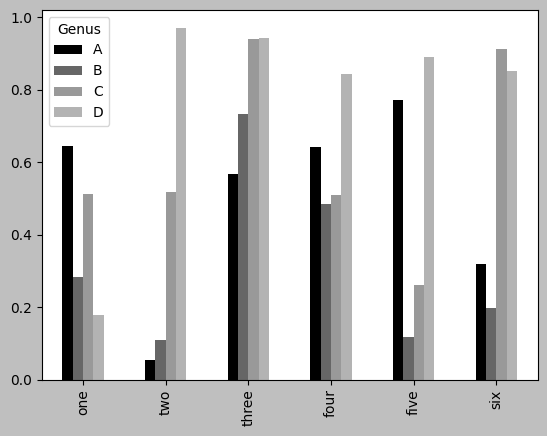

In [45]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df
df.plot.bar()

레스토랑의 팁 데이터셋 예제를 살펴볼 것임\
이 데이터에서 요일별로 열린 파티 개수를 계산하고 파티 개수 대비 팁 비율을 보여주는 누적 막대그래프를 그려보자\
read_csv 메서드를 사용해서 데이터를 불러오고 요일과 파티 개수에 따라 교차 테이블을 생성함

In [79]:
tips = pd.read_csv('https://github.com/wesm/pydata-book/blob/3rd-edition/examples/tips.csv?raw=True')
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [80]:
party_counts = pd.crosstab(tips['day'], tips['size'])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [82]:
party_counts.reindex(index=['Thur', 'Fri', 'Sat', 'Sun'])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [83]:
# 파티 인원이 1명이거나 여섯명인 파티는 데이터에서 많지 않으므로 제외함
party_counts = party_counts.loc[:,2:5]
party_counts

size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


In [85]:
# 합이 1이 되도록 정규화
party_pcts = party_counts.div(party_counts.sum(axis=1), axis=0)
party_pcts

size,2,3,4,5
day,,,,
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000
Thur,0.827586,0.068966,0.086207,0.017241


<Axes: xlabel='day'>

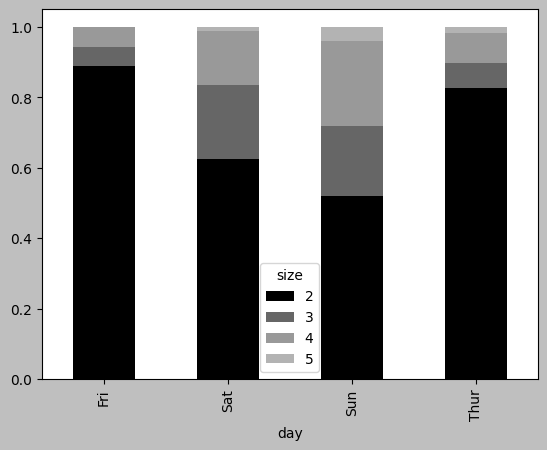

In [86]:
party_pcts.plot.bar(stacked=True)

In [87]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

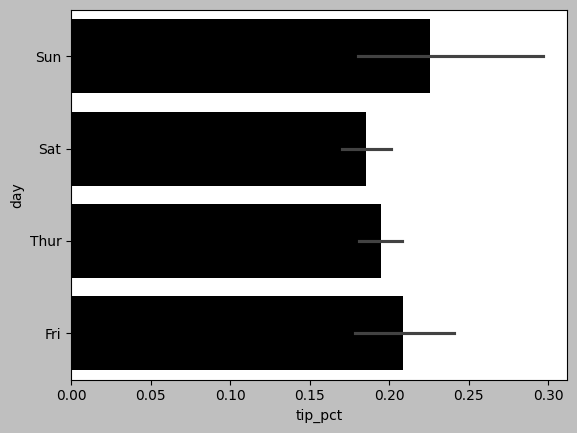

In [88]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

시본 그래프 함수의 data 인수는 판다스의 DataFrame을 받고 다른 인수들은 열 이름을 참조함\
day 열의 각 값에 대한 데이터는 여럿 존재하므로 tip_pct의 평균값으로 막대 그래프를 그림\
막대그래프 위에 겹쳐서 그려진 검은 선은 95%의 신뢰 구간(confidence interval)을 나타냄(이 값은 옵션 인수로 설정 가능)\
seaborn.barplot 메서드의 hue 옵션을 이용해서 추가 분류에 따라 나눠 그릴 수 있음

<Axes: xlabel='tip_pct', ylabel='day'>

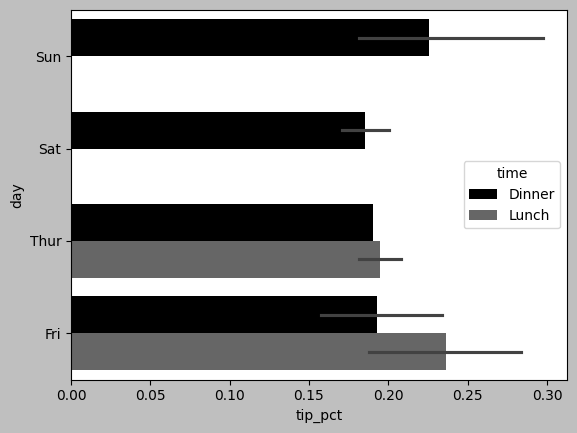

In [90]:
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

시본 라이브러리는 기본 색상표, 그래프 배경, 그리드 선 색상 같은 꾸밈새를 자동으로 변경함\
seaborn.set_style 메서드로 꾸밈새를 변경할 수 있음
```py
sns.set_style('whitegrid')
```
흑백 출력을 위한 그래프를 만들어야 한다면 색상표를 다음과 같이 흑백으로 변경하면 편리함
```py
sns.set_palette('Greys_r')
```

### 2.3 히스토그램과 밀도 그래프
히스토그램은 막대그래프의 한 종류로 갑스이 빈도를 분리해서 보여줌\
데이터 포인트는 분리되어 균일한 간격의 막대로 표현되며 데이터의 숫자가 막대의 높이로 표현됨\
팁 데이터를 사용해서 전체 결제 금액 대비 팁의 비율을 Series의 plot.hist 메서드를 사용해서 만들어보자

<Axes: ylabel='Frequency'>

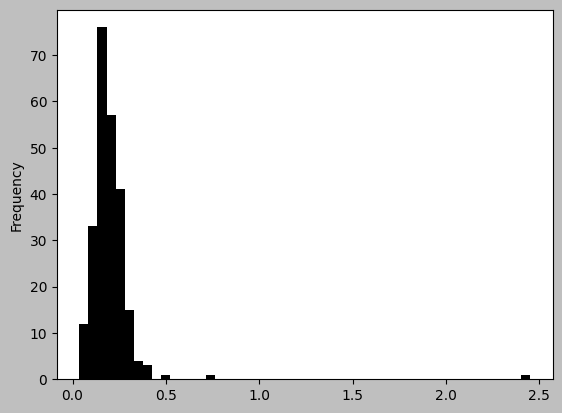

In [91]:
tips['tip_pct'].plot.hist(bins=50)

이와 관련된 다른 그래프로는 밀도 그래프가 있는데 이는 관찰값을 사용해서 추정되는 연속된 확률분포를 그림\
일반적인 과정은 kernel 메서드를 잘 섞어서 이 분포를 근사하는 방법인데 이보다 단순한 정규분포임\
따라서 밀도 그래프는 KDE(kernel density estimate, 커널 밀도 추정)그래프라고도 알려져 있음\
plot.density를 이용해서 밀도 그래프를 표준 KDE 형식으로 생성함

<Axes: ylabel='Density'>

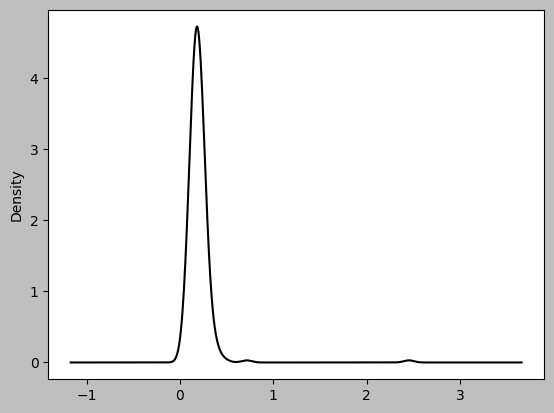

In [92]:
tips['tip_pct'].plot.density()

시본 라이브러리의 histplot 메서드를 이용해서 히스토그램과 밀도 그래프를 한 번에 손쉽게 그릴 수 있음\
예를 들어 두 개의 다른 표준정규분포로 이루어진 쌍봉 분포를 생각해보자

In [93]:
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))
values

0      -1.420842
1      -0.927499
2       1.296830
3      -1.213285
4       1.887549
         ...    
395     6.795870
396     6.862709
397    11.369961
398     8.158649
399    12.668130
Length: 400, dtype: float64

<Axes: ylabel='Count'>

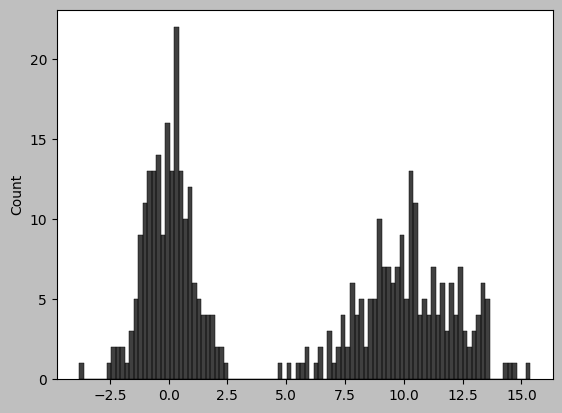

In [94]:
sns.histplot(values, bins=100, color="black")

### 2.4 산포도
산포도(scatter plot, point plot)는 두 개의 1차원 데이터 묶음 간의 관계를 나타낼 때 유용한 그래프

In [95]:
macro = pd.read_csv('https://github.com/wesm/pydata-book/blob/3rd-edition/examples/macrodata.csv?raw=True')
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


시본 라이브러리의 regplot 메서드를 이용해서 산포도와 선형 회귀선을 함께 그릴 수 있음

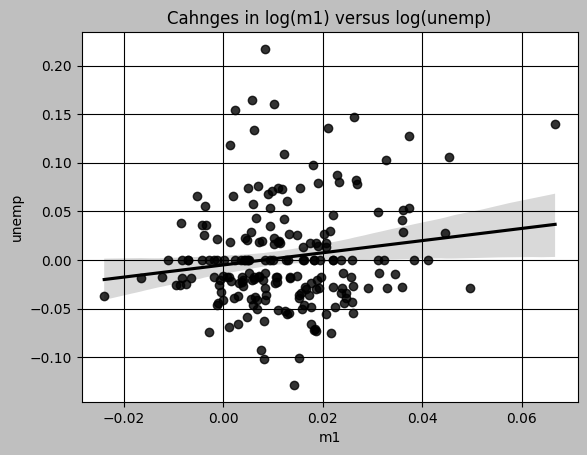

In [98]:
ax = sns.regplot(x='m1', y='unemp', data=trans_data)

ax.set_title('Cahnges in log(m1) versus log(unemp)')
ax.grid()

탐색적 데이터 분석에서는 변수 그룹 간의 모든 산포도를 살펴보는 일이 매우 유용한데 이를 짝지은(pair) 그래프 또는 산포도 행렬이라고 부름\
이런 그래프를 직접 그리려면 다소 복잡하므로 시본에서는 pairplot 함수를 제공함\
이 함수로 대각선을 따라 각 변수에 대한 히스토그램이나 밀도 그래프를 생성할 수 있음\
plot_kws 인수는 각 그래프에 전달할 개별 설정값을 지정하며 자세한 설정 옵션은 seaborn.pairplot 문서를 참고

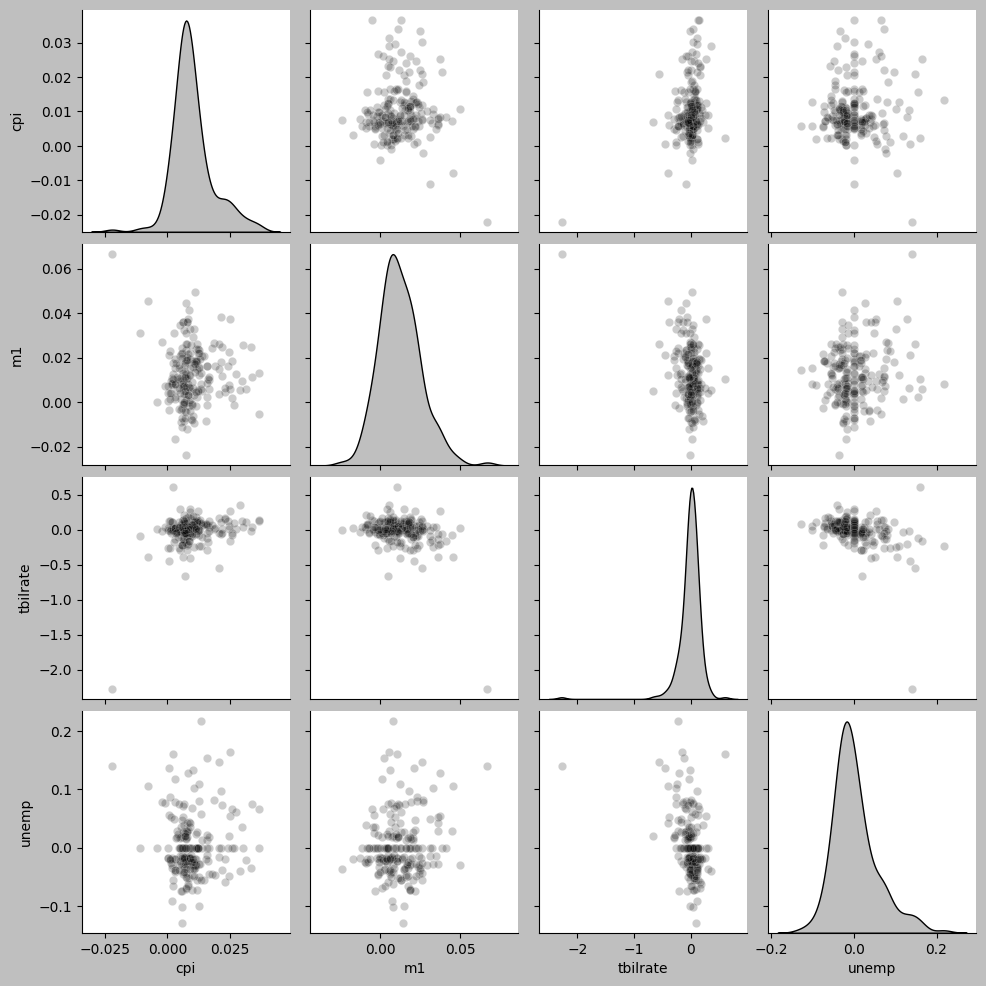

In [99]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha' : 0.2})

### 2.5 패싯 기릐드와 범주형 데이터
추가적인 그룹 차원을 가지는 데이터는 어떻게 시각화해야 할까?\
다양한 범주형 값을 갖는 데이터를 시각화하는 한 가지 방법은 패싯 그리드(facet grid)를 이용하는 것\
패싯 그리드는 2차원 레이아웃으로 그래프를 배치해 특정 변수의 구별되는 값을 각 축으로 비교할 수 있음\
시본의 유용한 내장 함수인 catplot을 이용해 다양한 측면을 나타내는 그래프를 쉽게 그릴 수 있음

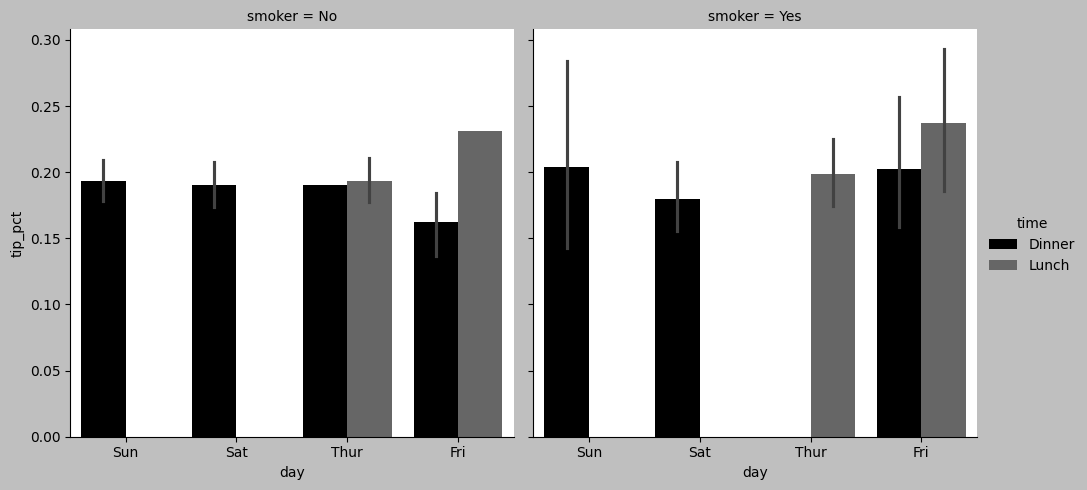

In [100]:
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])

'time'으로 그룹을 만드는 대신 패싯 안에서 막대그래프의 색깔을 달리해서 보여줄 수 있음\
또한 패싯 그리드에 time 값에 따른 그래프를 추가할 수도 있음

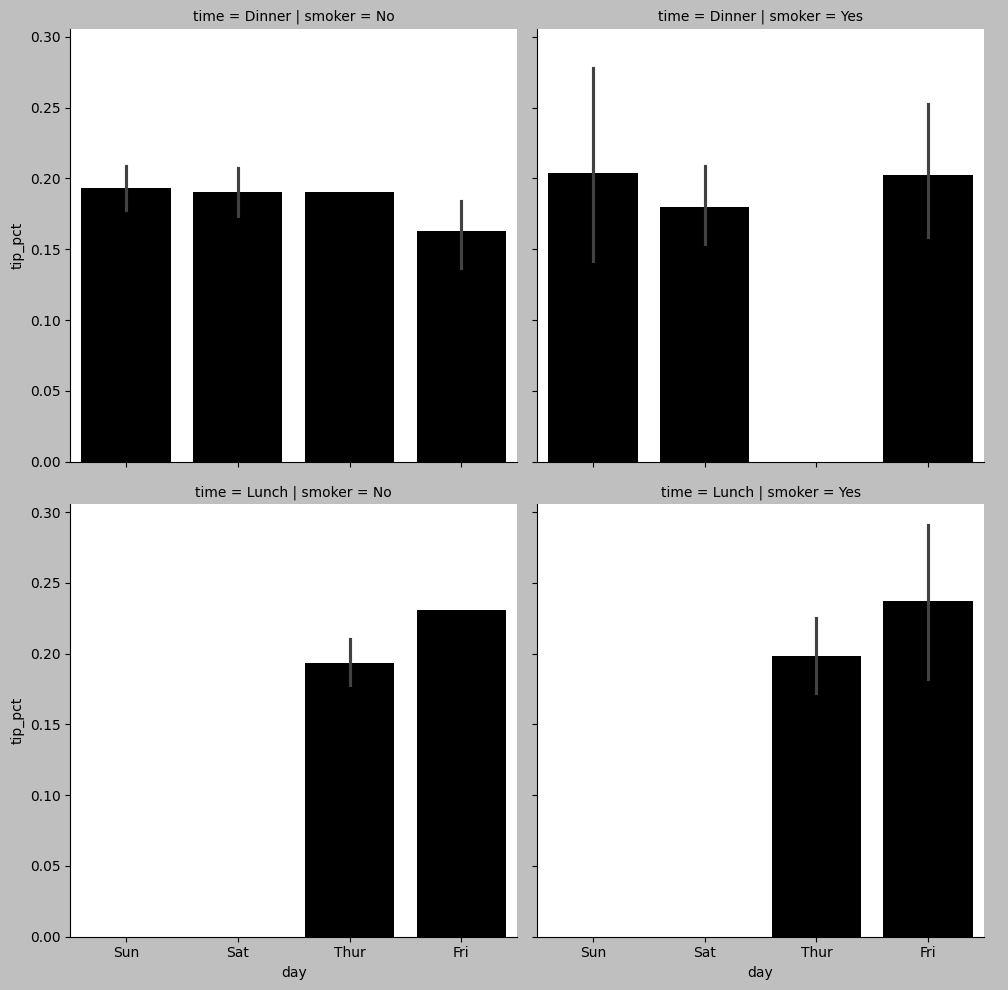

In [101]:
sns.catplot(x="day", y="tip_pct", row="time",
            col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])

catplot은 시각화 목적에 어울리는 여러 종류의 그래프도 지원하는데 예를 들어 중간값과 사분위수, 특이값을 보여주는 상자 그림(box plot)이 효과적인 시각화 방법일 수도 있음

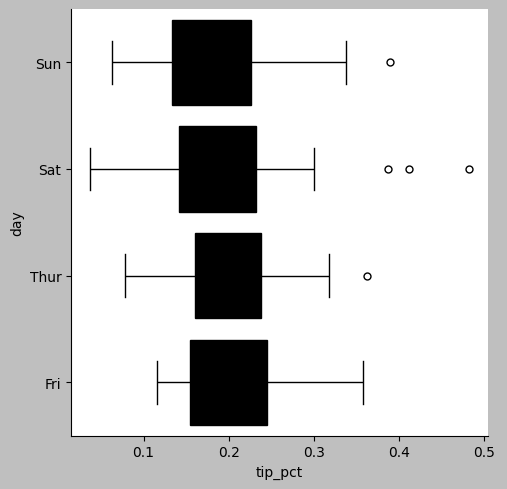

In [102]:
sns.catplot(x="tip_pct", y="day", kind="box",
            data=tips[tips.tip_pct < 0.5])